Intelligent Resume Screening System

Step 1 — Install & Import Required Libraries

In [1]:
!pip install -q PyPDF2 pdfplumber python-docx spacy scikit-learn pandas matplotlib openpyxl
!python -m spacy download en_core_web_sm -q
print("✅ All libraries installed successfully.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 713.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 56.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 12.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the

In [2]:
import os
import re
import io
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import PyPDF2
import pdfplumber
import docx
import spacy

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from google.colab import files

# Load spaCy English model (used for NLP-based skill extraction)
nlp = spacy.load("en_core_web_sm")

print(" Libraries imported and spaCy model loaded.")


✅ Libraries imported and spaCy model loaded.


Step 2 — Skill Database

In [3]:
SKILL_DB = [
    # Programming languages
    "python", "java", "c++", "c#", "javascript", "typescript", "r programming", "sql", "nosql",
    # AI / ML / Data
    "machine learning", "deep learning", "nlp", "natural language processing", "computer vision",
    "tensorflow", "pytorch", "keras", "scikit-learn", "pandas", "numpy", "opencv",
    "data analysis", "data visualization", "data engineering", "data science", "big data",
    "ocr", "tesseract", "spacy", "nltk", "hugging face", "transformers", "llm", "generative ai",
    # Cloud / DevOps
    "aws", "azure", "gcp", "docker", "kubernetes", "git", "github", "ci/cd", "linux",
    # Web development
    "django", "flask", "fastapi", "react", "node.js", "html", "css", "rest api", "api development",
    # Analytics tools
    "power bi", "tableau", "excel", "statistics", "a/b testing", "etl", "airflow", "spark", "hadoop",
    # Soft skills
    "communication", "leadership", "teamwork", "project management", "agile", "scrum"
]

print(f" Skill database loaded with {len(SKILL_DB)} skills.")


✅ Skill database loaded with 67 skills.


Step 3 — Text Extraction Functions

In [4]:
def extract_text_from_pdf(file_path):
    """Extract text from a PDF resume using pdfplumber (falls back to PyPDF2)."""
    text = ""
    try:
        with pdfplumber.open(file_path) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text += page_text + "\n"
    except Exception:
        pass

    if not text.strip():
        try:
            with open(file_path, "rb") as f:
                reader = PyPDF2.PdfReader(f)
                for page in reader.pages:
                    page_text = page.extract_text()
                    if page_text:
                        text += page_text + "\n"
        except Exception as e:
            print(f" Could not extract text from {file_path}: {e}")

    return text.strip()


def extract_text_from_docx(file_path):
    """Extract text from a DOCX resume (paragraphs + tables)."""
    text_parts = []
    doc = docx.Document(file_path)
    for para in doc.paragraphs:
        if para.text.strip():
            text_parts.append(para.text)
    for table in doc.tables:
        for row in table.rows:
            for cell in row.cells:
                if cell.text.strip():
                    text_parts.append(cell.text)
    return "\n".join(text_parts).strip()


def extract_text(file_path):
    """Route to the correct extractor based on file extension."""
    ext = os.path.splitext(file_path)[1].lower()
    if ext == ".pdf":
        return extract_text_from_pdf(file_path)
    elif ext == ".docx":
        return extract_text_from_docx(file_path)
    else:
        raise ValueError(f"Unsupported file type: {ext}. Please upload a PDF or DOCX file.")

print(" Text extraction functions ready.")


✅ Text extraction functions ready.


Step 4 — Upload Resumes

In [15]:
uploaded = files.upload()

resume_files = list(uploaded.keys())
print(f"\n Uploaded {len(resume_files)} resume(s):")
for f in resume_files:
    print("  -", f)


Saving Izzah_Resume.pdf to Izzah_Resume.pdf

✅ Uploaded 1 resume(s):
  - Izzah_Resume.pdf


In [16]:

resume_texts = {}

for fname in resume_files:
    try:
        text = extract_text(fname)
        resume_texts[fname] = text
        print(f"Extracted {len(text)} characters from {fname}")
    except Exception as e:
        print(f" Failed to process {fname}: {e}")

print(f"\nTotal resumes processed: {len(resume_texts)}")


✅ Extracted 766 characters from Izzah_Resume.pdf

Total resumes processed: 1


## Step 5 — Enter the Job Description
Paste the job description you want to match candidates against.

In [17]:
job_description = """
We are hiring a Python Developer with strong experience in Machine Learning,
Natural Language Processing (NLP), and Data Analysis. The ideal candidate has
hands-on experience with TensorFlow, scikit-learn, Pandas, Numpy, and SQL, along
with familiarity in Docker, Git, and REST API development. Experience with OCR,
text processing, and cloud platforms (AWS/GCP) is a strong plus. Excellent
communication and teamwork skills are required.
"""

print("✅ Job description loaded:\n")
print(job_description.strip())


✅ Job description loaded:

We are hiring a Python Developer with strong experience in Machine Learning,
Natural Language Processing (NLP), and Data Analysis. The ideal candidate has
hands-on experience with TensorFlow, scikit-learn, Pandas, Numpy, and SQL, along
with familiarity in Docker, Git, and REST API development. Experience with OCR,
text processing, and cloud platforms (AWS/GCP) is a strong plus. Excellent
communication and teamwork skills are required.


Step 6 — Skill Identification (Keyword Matching)

In [18]:
def extract_skills_keyword(text, skill_db=SKILL_DB):
    """Keyword-based skill extraction using whole-word/phrase matching."""
    text_lower = text.lower()
    found = []
    for skill in skill_db:
        pattern = r"(?<!\w)" + re.escape(skill.lower()) + r"(?!\w)"
        if re.search(pattern, text_lower):
            found.append(skill)
    return sorted(set(found))

keyword_skills = {name: extract_skills_keyword(text) for name, text in resume_texts.items()}

for name, skills in keyword_skills.items():
    print(f"📄 {name} -> {len(skills)} skills found:")
    print("   ", ", ".join(skills) if skills else "None found")
    print()


📄 Izzah_Resume.pdf -> 2 skills found:
    nlp, python



Step 7 (Upgrade) — NLP-based Skill Extraction

In [19]:
def extract_skills_nlp(text, skill_db=SKILL_DB):
    """NLP-based skill extraction using spaCy noun-chunk & entity analysis."""
    doc = nlp(text)

    candidate_phrases = set()
    for chunk in doc.noun_chunks:
        candidate_phrases.add(chunk.text.lower().strip())
    for ent in doc.ents:
        if ent.label_ in ("ORG", "PRODUCT", "LANGUAGE", "WORK_OF_ART"):
            candidate_phrases.add(ent.text.lower().strip())

    matched_skills = set()
    for skill in skill_db:
        skill_l = skill.lower()
        for phrase in candidate_phrases:
            if skill_l in phrase or phrase in skill_l:
                matched_skills.add(skill)
                break

        pattern = r"(?<!\w)" + re.escape(skill_l) + r"(?!\w)"
        if re.search(pattern, text.lower()):
            matched_skills.add(skill)

    return sorted(matched_skills)

nlp_skills = {name: extract_skills_nlp(text) for name, text in resume_texts.items()}

for name, skills in nlp_skills.items():
    print(f" {name} -> {len(skills)} skills (NLP) found:")
    print("   ", ", ".join(skills) if skills else "None found")
    print()


🤖 Izzah_Resume.pdf -> 3 skills (NLP) found:
    git, nlp, python



Step 8 — Resume Scoring & Job Matching

In [20]:
SIMILARITY_WEIGHT = 0.6
SKILL_WEIGHT = 0.4

def compute_similarity_scores(job_desc, resumes_dict):
    """TF-IDF cosine similarity between the JD and each resume."""
    names = list(resumes_dict.keys())
    docs = [job_desc] + [resumes_dict[n] for n in names]

    vectorizer = TfidfVectorizer(stop_words="english")
    tfidf_matrix = vectorizer.fit_transform(docs)

    jd_vector = tfidf_matrix[0:1]
    resume_vectors = tfidf_matrix[1:]
    sims = cosine_similarity(jd_vector, resume_vectors)[0]

    return {name: round(sim * 100, 2) for name, sim in zip(names, sims)}


def compute_skill_overlap(jd_skills, resume_skills):
    """% of JD-required skills present in the resume."""
    if not jd_skills:
        return 0.0
    overlap = set(jd_skills) & set(resume_skills)
    return round(len(overlap) / len(jd_skills) * 100, 2)



jd_skills = extract_skills_keyword(job_description)
print("🎯 Skills required by Job Description:", ", ".join(jd_skills))
print()

similarity_scores = compute_similarity_scores(job_description, resume_texts)

results = []
for name in resume_texts.keys():
    r_skills = sorted(set(keyword_skills.get(name, [])) | set(nlp_skills.get(name, [])))
    sim_score = similarity_scores[name]
    skill_score = compute_skill_overlap(jd_skills, r_skills)
    final_score = round(SIMILARITY_WEIGHT * sim_score + SKILL_WEIGHT * skill_score, 2)
    matched_keywords = sorted(set(jd_skills) & set(r_skills))

    results.append({
        "Candidate": name,
        "Similarity_Score(%)": sim_score,
        "Skill_Match(%)": skill_score,
        "Final_Score(%)": final_score,
        "Skills_Found": ", ".join(r_skills),
        "Matched_JD_Keywords": ", ".join(matched_keywords),
        "Num_Skills": len(r_skills)
    })

print("Scoring complete for all resumes.")


🎯 Skills required by Job Description: api development, aws, communication, data analysis, docker, gcp, git, machine learning, natural language processing, nlp, numpy, ocr, pandas, python, rest api, scikit-learn, sql, teamwork, tensorflow

✅ Scoring complete for all resumes.


## Step 9 — Candidate Ranking
All candidates are ranked from **best match to worst match** based on `Final_Score(%)`.

In [21]:
ranking_df = pd.DataFrame(results)
ranking_df = ranking_df.sort_values(by="Final_Score(%)", ascending=False).reset_index(drop=True)
ranking_df.index = ranking_df.index + 1
ranking_df.index.name = "Rank"

pd.set_option("display.max_colwidth", 60)
ranking_df


,Candidate,Similarity_Score(%),Skill_Match(%),Final_Score(%),Skills_Found,Matched_JD_Keywords,Num_Skills
Rank,,,,,,,
1,Izzah_Resume.pdf,8.48,15.79,11.4,"git, nlp, python","git, nlp, python",3


Step 10 (Upgrade) — AI Score **Dashboard**

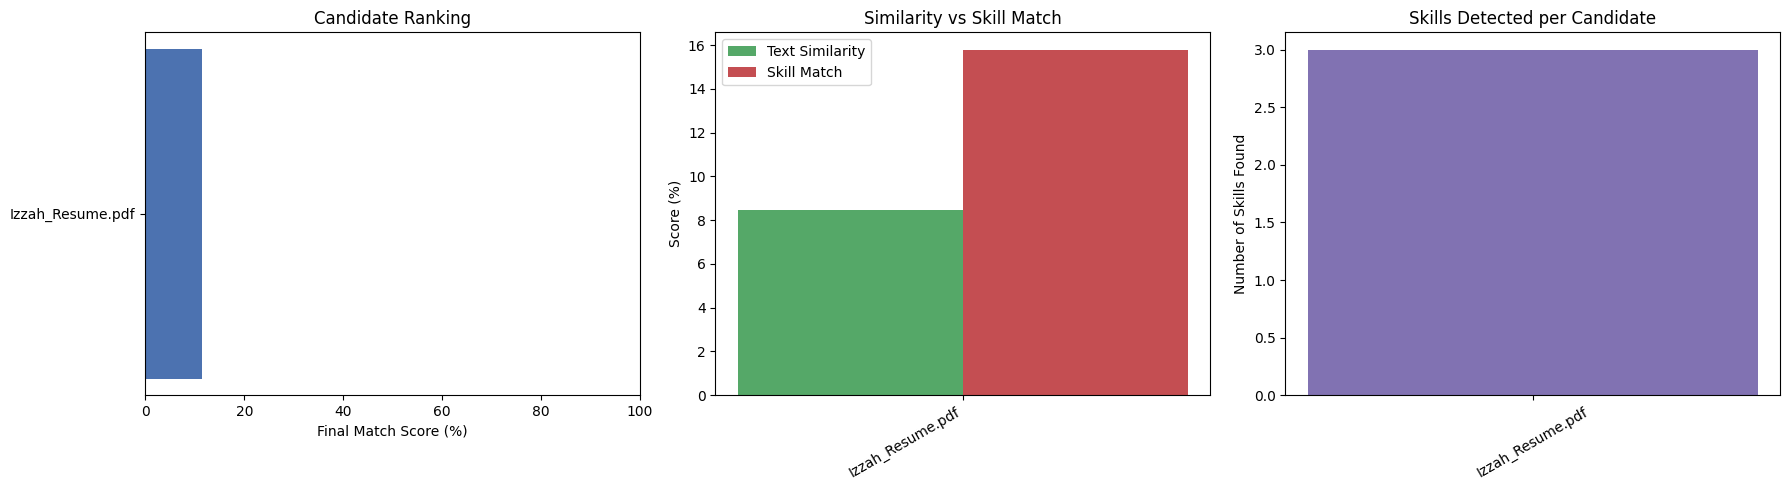

✅ Dashboard generated and saved as ai_score_dashboard.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


sorted_df = ranking_df.sort_values(by="Final_Score(%)")
axes[0].barh(sorted_df["Candidate"], sorted_df["Final_Score(%)"], color="#4C72B0")
axes[0].set_xlabel("Final Match Score (%)")
axes[0].set_title("Candidate Ranking")
axes[0].set_xlim(0, 100)


x = np.arange(len(ranking_df))
width = 0.35
axes[1].bar(x - width/2, ranking_df["Similarity_Score(%)"], width, label="Text Similarity", color="#55A868")
axes[1].bar(x + width/2, ranking_df["Skill_Match(%)"], width, label="Skill Match", color="#C44E52")
axes[1].set_xticks(x)
axes[1].set_xticklabels(ranking_df["Candidate"], rotation=30, ha="right")
axes[1].set_ylabel("Score (%)")
axes[1].set_title("Similarity vs Skill Match")
axes[1].legend()


axes[2].bar(ranking_df["Candidate"], ranking_df["Num_Skills"], color="#8172B2")
axes[2].set_ylabel("Number of Skills Found")
axes[2].set_title("Skills Detected per Candidate")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("ai_score_dashboard.png", dpi=150)
plt.show()

print(" Dashboard generated and saved as ai_score_dashboard.png")


***Step 11:Export Results***

In [23]:
csv_path = "resume_screening_results.csv"
xlsx_path = "resume_screening_results.xlsx"

ranking_df.to_csv(csv_path, index=True)
ranking_df.to_excel(xlsx_path, index=True)

print(f" Results exported to {csv_path} and {xlsx_path}")

files.download(csv_path)
files.download(xlsx_path)
files.download("ai_score_dashboard.png")


✅ Results exported to resume_screening_results.csv and resume_screening_results.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>